# ***PCA analysis -  Analisis de Componentes Principales*** 

![Image](https://i.vas3k.ru/7r0.jpg)

## **Ejemplo simple**

Digamos que tenemos dos variables, dimensiones o caracteristicas:

- Promomedio de hrs trabajadas (x)
- Ingresos (y)

Y queremos que esa varianza la reducimos a una sola dimension. 

PCA habla de, **entre mayor varianza**, mayor información se tiene para la reduccion de dimensionalidad.

## Teoria (no explicado)

## Dudas
### ¿La cantidad de Componentes se selecciona de forma arbitraria o con criterio?

No se eligen arbitrariamente, Se usan criterios estadísticos:

### 1. Por porcentaje de varianza explicada (el más común)

| Componente | Varianza explicada |
| ---------- | ------------------ |
| PC1        | 40%                |
| PC2        | 25%                |
| PC3        | 15%                |
| PC4        | 10%                |
| PC5        | 5%                 |

Suma acumulada

| Componentes           | Varianza acumulada |
| --------------------- | ------------------ |
| PC1                   | 40%                |
| PC1 + PC2             | 65%                |
| PC1 + PC2 + PC3       | 80%                |
| PC1 + PC2 + PC3 + PC4 | 90%                |

80% – 90% de varianza → suele ser un buen criterio. ya que 

10 variables → 4 componentes (90% información)


### 2. Con el gráfico Scree Plot

Se hace un gráfico con los componentes vs varianza.

La idea es encontrar el “codo” donde la mejora deja de ser grande.

### 3. Según el objetivo del análisis

| Objetivo             | Componentes     |
| -------------------- | --------------- |
| Visualización        | 2               |
| Visualización 3D     | 3               |
| Reducción para ML    | 5–20 aprox      |
| Mantener información | 90–95% varianza |

## ¿Se usan todas las variables o hay que seleccionar las variables para generar los componentes?

En Principal Component Analysis (PCA), normalmente se usan todas las variables originales para generar los componentes. No se eligen variables específicas para cada componente.

**A veces antes de aplicar PCA se filtran variables por criterio**

**Ejemplos:**

- variables irrelevantes

- variables categóricas mal codificadas

- variables con muy baja varianza

- variables duplicadas o muy correlacionadas


**Resumen claro**

- PCA usa todas las variables que le entregues.

- Cada componente es una combinación de todas las variables.

- Tú no eliges variables para cada componente.

- Lo único que decides es cuántos componentes mantener.

**Propositos de PCA**

- Muchas veces PCA se usa cuando:

- Hay muchas variables correlacionadas

- Se quiere condensar información

- Se quiere visualizar datos en 2D o 3D

## **Objetivos de PCA**

- Reducir dimensionalidad.
- Identificar qué variables pesan más.
- Visualizar la estructura de los datos.
- Usarlo después para visualizar clusters más claramente.

**Contenidos**

- Escalado (el mismo del cluster)
- PCA fit -> varianza explicada
- Plot de scree (gráfico de barras)
- Proyección PCA 2D y 3D

In [6]:
%load_ext kedro.ipython 
catalog.keys()

[03/07/26 01:54:04] INFO     Using                                                                  ]8;id=369456;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=300254;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\framework\project\__init__.py#270\270]8;;\
                             'C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\ke                
                             dro\framework\project\rich_logging.yml' as logging configuration.                     

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=412826;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=971568;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=971090;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=936343;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#65\65]8;;\

                    INFO     Resolved project path as: C:\Users\brand\Downloads\Proyecto_ML_Kedro.  ]8;id=866458;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=602427;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

2


[03/07/26 01:54:16] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=58386;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=616992;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro_telemetry\plugin.py#243\243]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[03/07/26 01:54:18] INFO     Kedro project machine_learning_project                                 ]8;id=933673;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=377398;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=827211;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=825337;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\
                             'pipelines'                                                                           

[03/07/26 01:54:19] INFO     Registered line magic 'run_viz'                                        ]8;id=344307;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=472227;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\ipython\__init__.py#153\153]8;;\


[
    'DataSetFIFA22',
    'DataSetFIFA21',
    'DataSetFIFA20',
    'preprocess_fifa_22',
    'preprocess_fifa_21',
    'preprocess_fifa_20',
    'FIFA22_processed_con_transformacion_columns',
    'FIFA21_processed_con_transformacion_columns',
    'FIFA20_processed_con_transformacion_columns',
    'model_input_table',
    'X_train_regression',
    'X_test_regression',
    'y_test_regression',
    'X_train_class',
    'X_test_class',
    'y_train_class',
    'y_test_class',
    'grid_linear_model',
    'grid_linear_multiple_model',
    'grid_svr_model',
    'grid_decision_tree_model',
    'grid_randomforest_model',
    'grid_logistic_model_classification',
    'grid_knn_model_classification',
    'grind_svc_cv_model_classification',
    'grid_decision_tree_model_classification',
    'grid_random_forest_model_classification',
    'y_pred_linear_regression',
    'y_pred_linear_multiple_regression',
    'y_pred_svr',
    'y_pred_decision_tree_regression',
    'y_pred_random_forest_regres

In [7]:
df_fifa = catalog.load("model_input_table")
df_fifa.info()

[03/07/26 01:54:20] INFO     Loading data from model_input_table (ParquetDataset)...           ]8;id=292126;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=153046;file://C:\Users\brand\Downloads\Proyecto_ML_Kedro\.venv\Lib\site-packages\kedro\io\data_catalog.py#1046\1046]8;;\

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44967 entries, 0 to 44966
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       44967 non-null  int64  
 1   Overall                   44967 non-null  int64  
 2   Potential                 44967 non-null  int64  
 3   Special                   44967 non-null  int64  
 4   International Reputation  44967 non-null  float64
 5   Weak Foot                 44967 non-null  float64
 6   Skill Moves               44967 non-null  float64
 7   Jersey Number             44967 non-null  float64
 8   Crossing                  44967 non-null  float64
 9   Finishing                 44967 non-null  float64
 10  HeadingAccuracy           44967 non-null  float64
 11  ShortPassing              44967 non-null  float64
 12  Volleys                   44967 non-null  float64
 13  Dribbling                 44967 non-null  float64
 14  Curve 

#### **Importaciónes**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
for i in df_fifa.columns:
    print(i)

Age
Overall
Potential
Special
International Reputation
Weak Foot
Skill Moves
Jersey Number
Crossing
Finishing
HeadingAccuracy
ShortPassing
Volleys
Dribbling
Curve
FKAccuracy
LongPassing
BallControl
Acceleration
SprintSpeed
Agility
Reactions
Balance
ShotPower
Jumping
Stamina
Strength
LongShots
Aggression
Interceptions
Positioning
Vision
Penalties
Composure
Marking
StandingTackle
SlidingTackle
GKDiving
GKHandling
GKKicking
GKPositioning
GKReflexes
Best Overall Rating
DefensiveAwareness
Offensive_Skills
Defensive_Skills
Overall_Class_Bin
Joined_Year
Joined_Month
Joined_Day
Height_cm
Weight_kg
Value_num
Wage_num
Release Clause_num
Year


### Correlación

- Una alta correlación puede significar una mayor probabilidad de redundancia, aun que PCA puede ayudarnos a reducirlo por correlaciones altas.

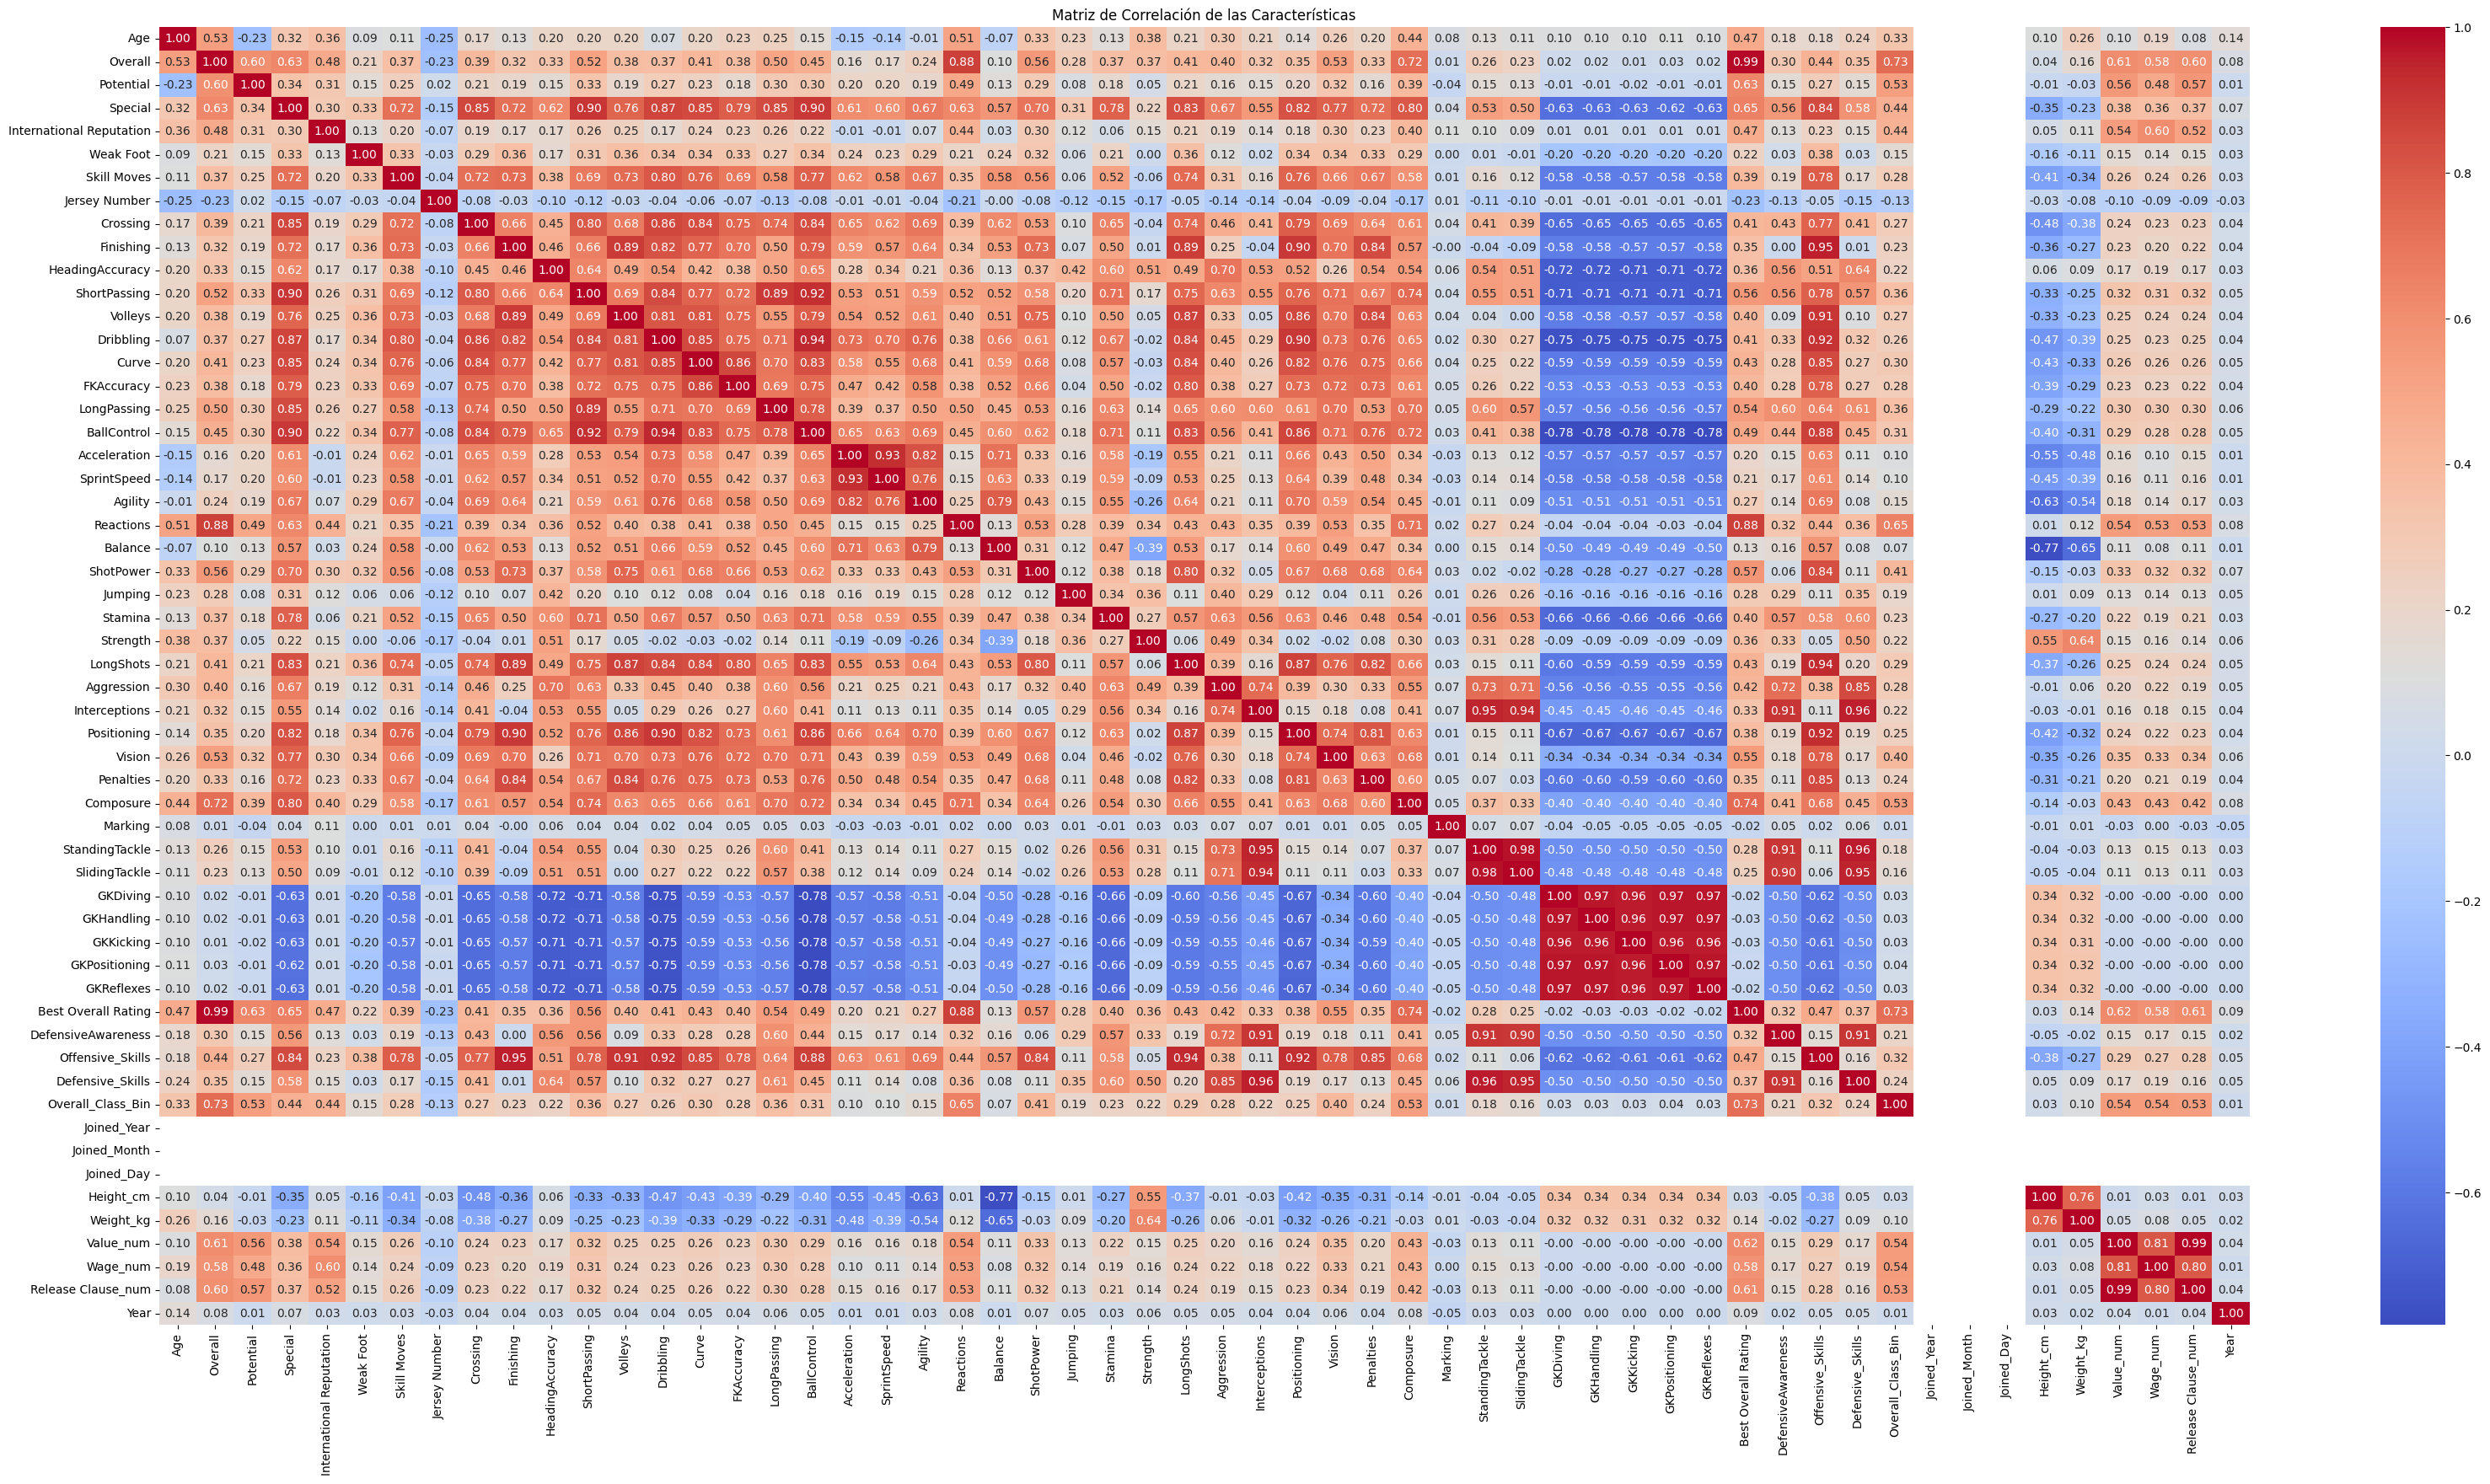

In [14]:
corr_matrix = df_fifa.corr()

plt.figure(figsize=(40, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de las Características')
plt.show()

cuando hay muchas correlaciones > 0.9, suele ser una buena señal para usar PCA, porque significa que la información está concentrada en menos dimensiones.

In [29]:
# Variavles que estan altamente correlacionadas
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.90)]

print(high_corr)

['ShortPassing', 'BallControl', 'SprintSpeed', 'Positioning', 'StandingTackle', 'SlidingTackle', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Best Overall Rating', 'DefensiveAwareness', 'Offensive_Skills', 'Defensive_Skills', 'Release Clause_num']


## **Varianza**

- Visualizando las varianzas en general

In [31]:
df_fifa.var()


Age                                     23.294216
Overall                                  49.14764
Potential                               33.796339
Special                              69876.309567
International Reputation                 0.187195
Weak Foot                                 0.45485
Skill Moves                              0.600798
Jersey Number                          309.381533
Crossing                                318.71369
Finishing                              374.854698
HeadingAccuracy                        286.903747
ShortPassing                           195.324602
Volleys                                311.672286
Dribbling                              327.308137
Curve                                  329.972978
FKAccuracy                             300.255774
LongPassing                              219.4395
BallControl                            254.317704
Acceleration                           217.259936
SprintSpeed                            210.214707

### **Variables con menor varianza**

Las Variables o features con varianza baja son:

- Joined_Month
- Joined_Day
- Joined_Year
- International Reputation
- Overall_Class_Bin
- Weak Foot
- Skill 
- Year

In [32]:
df_fifa.var().sort_values()


Joined_Month                                  0.0
Joined_Day                                    0.0
Joined_Year                                   0.0
International Reputation                 0.187195
Overall_Class_Bin                        0.189449
Weak Foot                                 0.45485
Skill Moves                              0.600798
Year                                      0.65703
Age                                     23.294216
Potential                               33.796339
Best Overall Rating                     46.618229
Height_cm                               46.706034
Overall                                  49.14764
Weight_kg                               50.748939
Reactions                               84.047657
Marking                                102.450088
Composure                              140.934298
Jumping                                143.253889
Strength                               161.012034
ShotPower                              177.284632

### **Escalado**

Diferentes características pueden tener unidades y escalas diferentes, como el salario frente a la edad. Para compararlas de forma justa, el PCA primero estandariza los datos haciendo que cada característica tenga

- Una media de 0
- Una desviación estándar de 1

Tambien se observara los cambios de la varianza

### **Dataframe con variables escaladas**
Se usara este dataframe para PCA

In [39]:
df_fifa_scaled = pd.DataFrame(df_fifa_scaled, columns=df_fifa.columns)

In [40]:
df_fifa_scaled.var().sort_values()


Joined_Month                0.000000
Joined_Day                  0.000000
Joined_Year                 0.000000
Potential                   1.000022
Stamina                     1.000022
Crossing                    1.000022
SprintSpeed                 1.000022
LongPassing                 1.000022
Volleys                     1.000022
Curve                       1.000022
HeadingAccuracy             1.000022
ShortPassing                1.000022
FKAccuracy                  1.000022
International Reputation    1.000022
Overall                     1.000022
Age                         1.000022
Positioning                 1.000022
Interceptions               1.000022
LongShots                   1.000022
BallControl                 1.000022
Agility                     1.000022
ShotPower                   1.000022
Strength                    1.000022
Acceleration                1.000022
Vision                      1.000022
Aggression                  1.000022
GKDiving                    1.000022


In [41]:
df_fifa_scaled.drop(columns=["Joined_Month","Joined_Day","Joined_Year"])

,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,...,DefensiveAwareness,Offensive_Skills,Defensive_Skills,Overall_Class_Bin,Height_cm,Weight_kg,Value_num,Wage_num,Release Clause_num,Year
0,0.234957,3.023569,2.852359,2.695629,4.306602,0.029017,2.009809,-0.176928,1.999784,1.829074,...,1.233527,1.959224,1.083020,1.714134,-0.316004,-0.847057,15.792116,11.505694,15.757432,1.227864
1,0.234957,2.880925,2.680342,2.593487,6.617907,1.511777,0.719658,-0.745463,1.327603,1.777424,...,1.334863,1.872523,1.881279,1.714134,1.147245,0.977824,13.601588,6.200970,12.117512,1.227864
2,1.892523,3.023569,2.680342,2.567006,8.929211,1.511777,0.719658,-0.688610,1.607678,2.345578,...,-0.286507,2.175976,0.395289,1.714134,0.122971,1.118200,6.274652,5.959846,6.700685,1.227864
3,0.856544,2.452993,1.992276,2.510261,1.995297,0.029017,2.009809,-0.120074,1.999784,0.951018,...,1.638869,1.525718,1.783032,1.714134,-1.340279,-0.847057,5.141620,1.619617,5.643934,1.227864
4,0.234957,3.166213,3.024375,2.476213,6.617907,1.511777,0.719658,-0.859171,2.223844,1.054319,...,1.892208,1.395667,1.733908,1.714134,-0.608654,-0.004804,15.867651,7.165465,14.144908,1.227864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44962,-1.629804,-2.396903,-0.071921,-3.236163,-0.316007,-1.453742,-1.860645,1.130704,-2.257358,-2.148003,...,-2.009212,-2.462528,-2.048612,-0.583385,0.561945,-1.427699,-0.440448,-0.309373,-0.429410,-1.239552
44963,-1.215413,-2.396903,-2.136119,-3.270210,-0.316007,-1.453742,-1.860645,1.016997,-2.201343,-2.044703,...,-2.009212,-2.289126,-2.245107,-0.583385,1.293570,0.864537,-0.442714,-0.309373,-0.433715,-1.239552
44964,-1.422608,-2.396903,-1.964102,-3.296691,-0.316007,0.029017,-1.860645,0.505315,-2.145328,-2.148003,...,0.220171,-2.765981,-2.022004,-0.583385,0.269296,0.673517,-0.442714,-0.502272,-0.433089,-1.239552
44965,-1.422608,-2.254259,-0.415954,-3.304257,-0.316007,-1.453742,-1.860645,3.234285,-2.257358,-2.044703,...,0.220171,-2.679280,-2.032238,-0.583385,1.293570,0.546171,-0.438937,-0.309373,-0.426827,-1.239552


### **Features**

- No se seleccionaran features irrelevantes, repetidas o muy correlaciónadas.
- No se utilizara variables categoricas no codificadas.
- Variables con baja varianza

In [77]:
features = [

"Age",
"Overall",
"Potential",
"Special",
"International Reputation",
"Weak Foot",
"Skill Moves",
"Crossing",
"Finishing",
"HeadingAccuracy",
"ShortPassing",
"Volleys",
"Dribbling",
"Curve",
"FKAccuracy",
"LongPassing",
"BallControl",
"Acceleration",
"SprintSpeed",
"Agility",
"Reactions",
"Balance",
"ShotPower",
"Jumping",
"Stamina",
"Strength",
"LongShots",
"Aggression",
"Interceptions",
"Positioning",
"Vision",
"Penalties",
"Composure",
"Marking",
"StandingTackle",
"SlidingTackle",
"GKDiving",
"GKHandling",
"GKKicking",
"GKPositioning",
"GKReflexes",
"Best Overall Rating",
"DefensiveAwareness",
"Offensive_Skills",
"Defensive_Skills",
"Overall_Class_Bin",
"Height_cm",
"Weight_kg",
"Value_num",
"Wage_num",
"Release Clause_num",
]

"""
descartados
"Year",
"Jersey Number",

"""

# dataframe escalado
X = df_fifa_scaled[features]

#### **Entrenar PCA sin límite de componentes**

In [78]:
pca = PCA()
pca_fit = pca.fit(X)

explained_variance = pca_fit.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

#### **Gráfico: Varianza explicada y acumulada**

Al analizar el gráfico de varianza acumulada del PCA, se observa que los primeros 14 componentes principales permiten explicar aproximadamente el 90% de la varianza total del conjunto de datos. En el gráfico, cada punto representa un componente principal y la línea roja indica el umbral del 90% de varianza acumulada, lo que permite identificar visualmente el número mínimo de componentes necesarios para representar la mayor parte de la información del dataset.

**Los puntos:** representan cada componente principal (PC)

**la línea roja:** representa el umbral del 90% de varianza acumulada

**Intersección con PC14:** indica cuántos componentes se necesitan

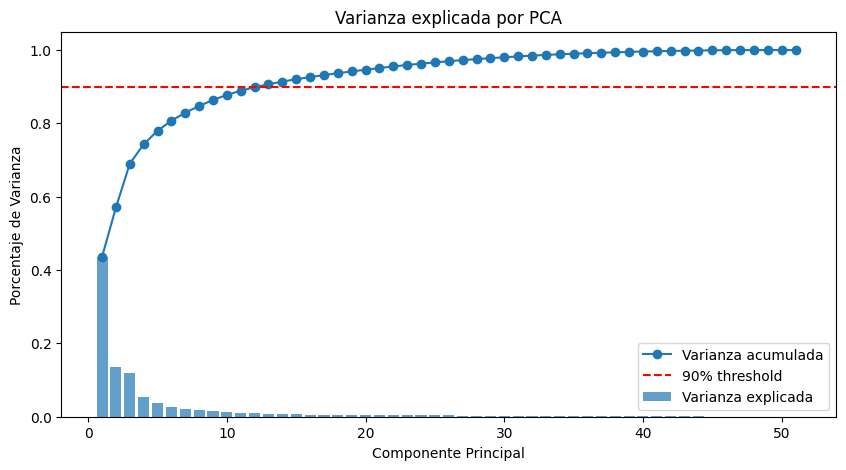

In [79]:
plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label="Varianza explicada")
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', label="Varianza acumulada")
plt.axhline(0.90, color='red', linestyle='--', label="90% threshold")
plt.xlabel("Componente Principal")
plt.ylabel("Porcentaje de Varianza")
plt.title("Varianza explicada por PCA")
plt.legend()
plt.show()

### **Tabla de varianza explicada**

In [80]:
pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

,PC,Explained Variance,Cumulative Variance
0,PC1,4.359426e-01,0.435943
1,PC2,1.347149e-01,0.570657
2,PC3,1.193831e-01,0.690041
3,PC4,5.304394e-02,0.743085
4,PC5,3.667814e-02,0.779763
5,PC6,2.767771e-02,0.807440
6,PC7,2.177601e-02,0.829216
7,PC8,1.816930e-02,0.847386
8,PC9,1.650205e-02,0.863888
9,PC10,1.366228e-02,0.877550


### **Suma acumulada**

**Interpretacion**

Los primeros 14 componentes principales explican aproximadamente el 90% de la varianza total del dataset. (ya verificado en el grafico, aqui solo vemos desde otro punto de vista)

In [81]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.43594256 0.57065744 0.69004057 0.74308451 0.77976265 0.80744037
 0.82921638 0.84738567 0.86388772 0.87755    0.88906384 0.89864154
 0.90664437 0.91402067 0.92049173 0.92628782 0.93172302 0.93692586
 0.94166602 0.94636637 0.95088894 0.95528962 0.9591738  0.9629507
 0.96633152 0.96968106 0.97261857 0.97530268 0.97786056 0.9803102
 0.98260482 0.98480192 0.98675411 0.98849599 0.99004275 0.99140573
 0.99263455 0.9938402  0.99497109 0.99605837 0.99680006 0.99748385
 0.99812014 0.99874523 0.99930664 0.99973415 0.99988343 0.9999905
 0.99999838 1.         1.        ]


## loadings

Loadings o cargas singifica cuanto contribuye cada variable original a un componente pricipal.

| Valor       | Interpretación      |
| ----------- | ------------------- |
| cercano a 0 | poca influencia     |
| ±0.3        | influencia moderada |
| ±0.5 o más  | influencia fuerte   |


## Interpretación de un componente (IMPORTANTICIMO)

Como ejemplo miremos los loadings de PC1

| Variable     | Loading PC1 |
| ------------ | ----------- |
| Acceleration | 0.55        |
| SprintSpeed  | 0.57        |
| Agility      | 0.52        |
| Strength     | 0.10        |

- Como las caracteristicas de Acceleration y SprintSpeed son altas entonces PC1 representa velocidad/agilidad

#### **Loadings (importancia de cada feature en cada PC)**

In [82]:
loadings = pd.DataFrame(
    pca_fit.components_.T,
    columns=[f"PC{i+1}" for i in range(len(explained_variance))],
    index=features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51
Age,0.044896,0.179495,-0.051111,0.226764,0.376789,0.100009,0.314764,-0.260376,-0.035204,-0.135906,...,0.001737,0.014716,-0.013523,0.001413,0.011295,-0.058200,0.012964,-0.001780,-0.000786,0.000000e+00
Overall,0.111357,0.263821,-0.145319,-0.032788,0.075043,0.141508,-0.067938,0.097415,-0.024534,0.031906,...,-0.064680,0.009452,-0.007749,-0.005384,-0.015458,0.708884,-0.096680,0.013514,0.002276,-3.611276e-15
Potential,0.069484,0.149039,-0.122003,-0.234438,-0.242278,-0.010429,-0.329754,0.352826,0.038390,0.317107,...,0.013431,0.009023,-0.009118,0.003272,0.008355,-0.011945,0.017792,0.000230,-0.000473,2.503463e-16
Special,0.205444,0.055467,-0.006172,-0.009834,0.098918,0.059784,-0.022785,0.010281,-0.020124,-0.047870,...,0.025082,-0.001287,-0.003460,0.001831,0.002418,-0.012861,0.002493,0.482019,0.812931,2.106809e-12
International Reputation,0.059140,0.179889,-0.120623,-0.033236,-0.073116,-0.244539,0.393785,-0.181698,0.021224,0.079138,...,0.000714,-0.001152,0.002605,0.000370,0.001861,0.001339,-0.017738,0.000724,-0.000221,-1.419233e-15
Weak Foot,0.075844,-0.017422,-0.084306,0.041885,0.012923,-0.007792,-0.027917,0.024902,0.976505,-0.137359,...,-0.002214,0.001038,0.000094,0.003097,-0.001774,-0.001083,-0.000145,-0.000061,-0.000137,-6.029702e-16
Skill Moves,0.167361,-0.074528,-0.088028,-0.003370,-0.004942,-0.032028,-0.025418,0.009823,-0.007256,-0.079712,...,0.013916,-0.003327,0.000891,0.002040,-0.014652,0.000264,-0.000630,0.000238,0.000493,-2.878853e-15
Crossing,0.184397,-0.047476,-0.004740,-0.070705,0.120062,-0.045323,-0.015807,-0.010340,-0.060071,-0.178765,...,0.032501,-0.012948,0.002570,0.004550,0.013496,-0.030022,0.005933,-0.033733,-0.055368,-1.418014e-13
Finishing,0.167436,-0.106274,-0.146176,0.169235,-0.068030,-0.003339,-0.019397,-0.010719,-0.029910,0.049226,...,0.070917,-0.015586,0.002001,0.013877,-0.024624,0.016705,-0.001436,-0.022840,-0.041518,-3.530154e-01
HeadingAccuracy,0.142412,0.074138,0.157628,0.208179,-0.208271,0.062348,0.065044,0.004994,0.018519,0.224343,...,-0.002200,0.000167,-0.008430,0.002486,0.018526,0.000009,0.001521,-0.030787,-0.051797,-1.353345e-13


### **Las variables con mas importancia en los 14 componentes**

#### **Interpretación de los componentes**

**PC1 - Habilidades ofensivas / técnicas**

**Interpretación:**

PC1 representa habilidades ofensivas y técnicas del jugador.

**PC2 - Calidad general / valor del jugador**

**Interpretación:**

PC2 representa el nivel general y valor de mercado del jugador.

Relaciona rating, valor económico y atributos físicos.

**PC3 - Habilidades defensivas**

**Interpretación:**

PC3 representa las habilidades defensivas del jugador.

Tackles, intercepciones y awareness defensivo.

**PC4 - Características físicas**

**Interpretación:**

PC4 representa atributos físicos y corporales del jugador.

Altura, peso y fuerza.

**PC5 - Edad y valor potencial**

**Interpretación:**

PC5 representa la relación entre edad, potencial y valor económico.

**PC6 - Velocidad y explosividad**

**Interpretación:**

PC6 representa capacidades físicas atléticas (velocidad y explosividad).

### Conclusion final

Despues de los 7 componentes, se puede ver que no se logra una correcta interpretación ya que se empiezan a mezclar variables.

- Se eliminan year y number_jersey ya que no aportan como habilidades para los jugadores, generando componentes mas limpios.

- Se visualizan las 5 primeras variables mas importantes ya que mas de 10 obtienen valores debiles.

In [90]:
for pc in loadings.columns[:14]:
    print(f"\nTop variables {pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))


Top variables PC1
Special             0.205444
BallControl         0.203277
Dribbling           0.197511
ShortPassing        0.196356
Offensive_Skills    0.189016
Name: PC1, dtype: float64

Top variables PC2
Overall                0.263821
Best Overall Rating    0.255422
Reactions              0.239367
Strength               0.225863
Overall_Class_Bin      0.219769
Name: PC2, dtype: float64

Top variables PC3
SlidingTackle         0.295706
StandingTackle        0.289223
Defensive_Skills      0.279224
Interceptions         0.269751
DefensiveAwareness    0.266442
Name: PC3, dtype: float64

Top variables PC4
Weight_kg    0.328769
Strength     0.323539
Height_cm    0.292139
Balance      0.247178
Potential    0.234438
Name: PC4, dtype: float64

Top variables PC5
Age                   0.376789
Release Clause_num    0.313186
Value_num             0.306689
Wage_num              0.244384
Potential             0.242278
Name: PC5, dtype: float64

Top variables PC6
Jumping                     0.5

#### **Gráfico de heatmap de loadings**

Rojo: influencia positiva fuerte

Azul: influencia negativa fuerte

Blanco: poca influencia

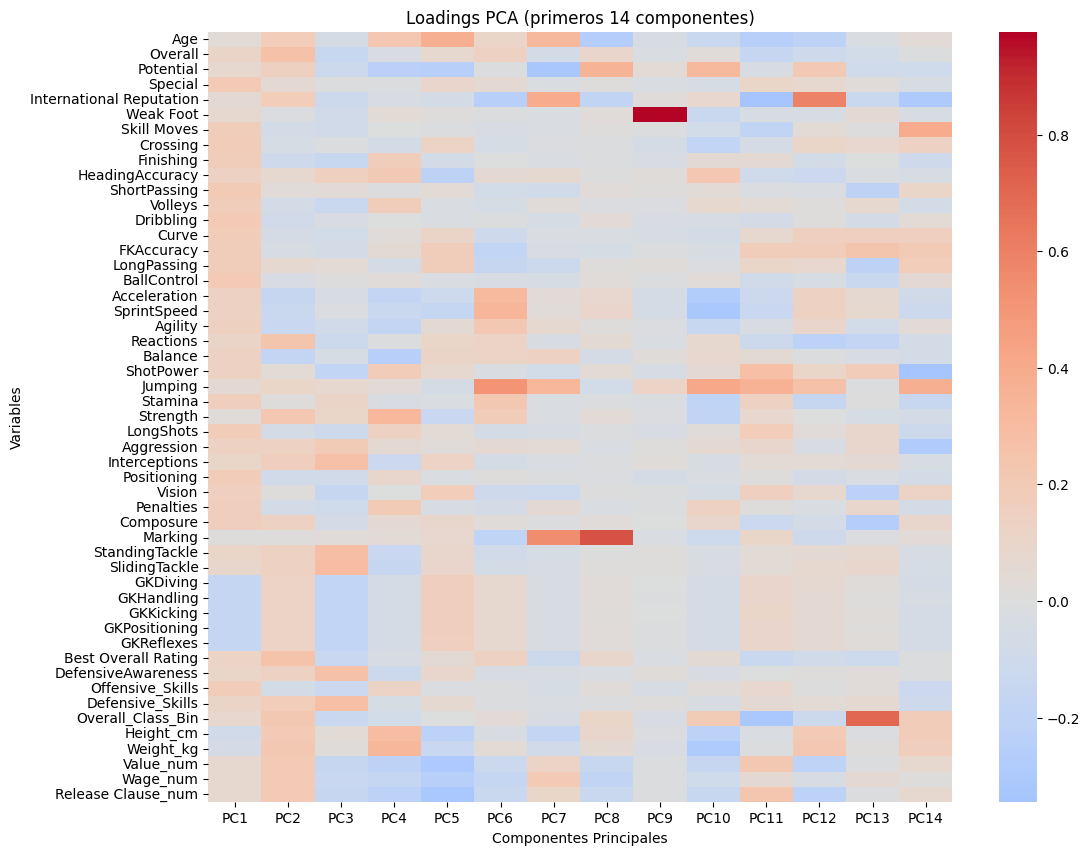

In [85]:
plt.figure(figsize=(12,10))

sns.heatmap(
    loadings.iloc[:, :14],   # solo los 14 componentes
    cmap="coolwarm",
    center=0
)

plt.title("Loadings PCA (primeros 14 componentes)")
plt.xlabel("Componentes Principales")
plt.ylabel("Variables")
plt.show()

#### **Reducir a 2 componentes para visualización**

In [86]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_fifa_scaled["PC1"] = X_pca_2[:, 0]
df_fifa_scaled["PC2"] = X_pca_2[:, 1]

#### **Scatterplot 2D**

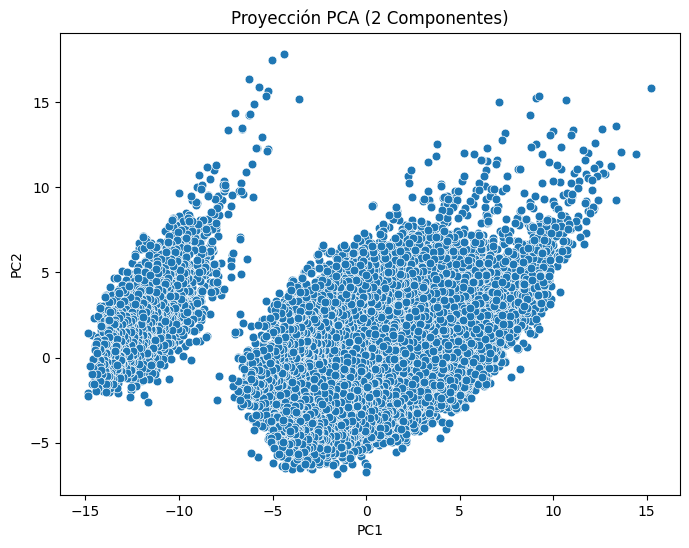

In [87]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=df_fifa_scaled, s=40)
plt.title("Proyección PCA (2 Componentes)")
plt.show()


##### **Biplot**

- Uno de los gráficos MÁS relevantes para PCA.

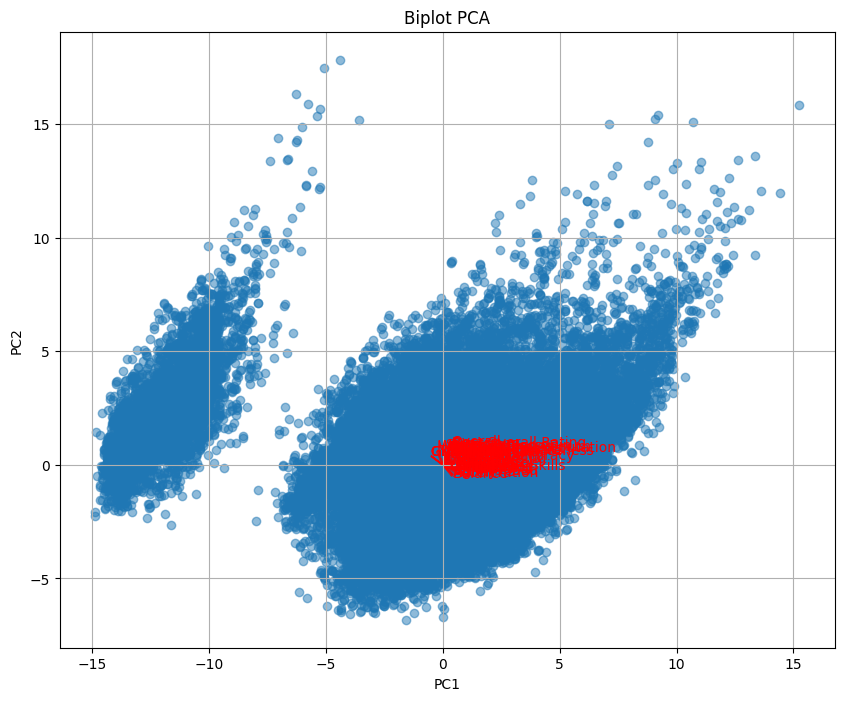

In [88]:
plt.figure(figsize=(10,8))

# Scatter
plt.scatter(df_fifa_scaled["PC1"], df_fifa_scaled["PC2"], alpha=0.5)

# Setas de loadings
for i, feature in enumerate(features):
    plt.arrow(0, 0, 
              loadings.iloc[i,0]*3, 
              loadings.iloc[i,1]*3, 
              color='red', alpha=0.7)
    plt.text(loadings.iloc[i,0]*3.2, 
             loadings.iloc[i,1]*3.2, 
             feature, color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA")
plt.grid(True)
plt.show()


## **Conclusiones**

### 1. Variables descartadas

- Se descantan Jersey Number y Year ya que no representan habilidades de jugador
- Se descartan variables con nula varianza luego del escalado de variables.

### 2. Seleccion de componentes

Segun el grafico, los 14 componentes seleccionados explican aproximadamente el 90% de la varianza total del conjunto de datos, permitiendo reducir significativamente la dimensionalidad manteniendo la mayor parte de la información.

Se generan codigos para visualizar la varianza por cada componentes y se realiza un codigo que suma la varianza acumulada confirmando que 14 componenes explican el 90& de la varianza total del conjunto de datos.

#### 3. loadings

El análisis de los loadings del PCA muestra que los primeros componentes capturan patrones claros en los datos.

El primer componente (PC1) está dominado por variables relacionadas con habilidades ofensivas y técnicas como Ball Control, Dribbling y Short Passing.

El segundo componente (PC2) refleja la calidad general del jugador y su valor de mercado, con altas contribuciones de Overall Rating, Value y Wage.

El tercer componente (PC3) representa habilidades defensivas como Sliding Tackle, Standing Tackle e Interceptions.

### Uso con clustering

Los componentes principales obtenidos mediante Principal Component Analysis pueden utilizarse como nuevas variables para aplicar algoritmos de Cluster Analysis.

El uso de PCA previo al clustering presenta varias ventajas:

- **Reducción de dimensionalidad:** permite reducir el número de variables originales a un conjunto menor de componentes que conservan la mayor parte de la información del dataset.

- **Eliminación de colinealidad:** muchas variables originales presentan alta correlación entre sí, lo que puede afectar el desempeño de los algoritmos de clustering. Los componentes principales son ortogonales entre sí, evitando este problema.

- **Reducción de ruido:** al concentrar la mayor parte de la varianza en los primeros componentes, se descartan componentes con baja varianza que pueden representar ruido en los datos.

- **Mejor visualización:** los primeros componentes pueden utilizarse para representar los datos en 2 o 3 dimensiones, facilitando la interpretación de los clusters.

En este caso, se utilizarán los componentes principales obtenidos del PCA como variables de entrada para aplicar técnicas de clustering, lo que permitirá identificar grupos de jugadores con características similares en función de sus habilidades técnicas, físicas y defensivas.

El uso combinado de PCA y clustering permite descubrir patrones y estructuras en los datos que no son fácilmente identificables utilizando únicamente las variables originales.

De esta forma, el clustering permitirá identificar perfiles de jugadores con características similares, como jugadores con alto perfil ofensivo, defensivo o físico.

#### **Visualizar clusters sobre PCA**

In [64]:
#plt.figure(figsize=(8,6))
#sns.scatterplot(x=df_fifa_scaled["PC1"], y=df_fifa_scaled["PC2"], hue=df_fifa_scaled["KMeans_cluster"], palette="tab10")
#plt.title("Clusters KMeans en Espacio PCA")
#plt.show()